<a href="https://colab.research.google.com/github/AlejoCNYT/AutoStudy/blob/main/NumPy_para_TensorizedChol.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧮 NumPy desde cero: las 4 piezas para entender `TensorizedChol`

> **Para quién es este notebook.** Para alguien que nunca trabajó con NumPy y
> necesita, antes o ahora, entender qué hace `TensorizedChol` (la versión
> factorizada por Cholesky del clasificador QDA) implementado en el TP1 de AMIA.
>
> **Qué vas a aprender.** Cuatro ideas fundamentales, en este orden:
>
> 1. **`.shape`** — cómo NumPy "ve" los datos como cajas de varias dimensiones.
> 2. **`@`** — el operador de producto matricial (no es `*`).
> 3. **`axis`** — cómo reducir una dimensión sin perder el resto.
> 4. **Cholesky** — qué es `A = L·Lᵀ` y por qué nos sirve.
>
> Al final hay una sección **puente** que muestra dónde encaja cada pieza en
> `TensorizedChol`.

---

## Índice

1. [Sección 1 — `shape`: la geometría de los arrays](#sec1)
2. [Sección 2 — `@`: el producto matricial](#sec2)
3. [Sección 3 — `axis`: reducir una dimensión](#sec3)
4. [Sección 4 — Cholesky: factorizar para acelerar](#sec4)
5. [Sección 5 — Puente a `TensorizedChol`](#sec5)

---

### Cómo leer este notebook

- Cada sección tiene **celdas de teoría** (texto) seguidas de **celdas de código ejecutable**.
- Ejecutá las celdas con `Shift + Enter` o `Ctrl + Enter`.
- Las visualizaciones son prints coloreados en consola y figuras con `matplotlib`.
- Si algo no se entiende, releé la teoría de esa misma sección antes de avanzar.

¡Vamos!


<a id="sec1"></a>
# 📦 Sección 1 — `shape`: la geometría de los arrays

## 1.1 La idea central

NumPy organiza los datos en **arrays** (también llamados **tensores**). Cada
array tiene una propiedad mágica: `.shape`, una tupla que te dice **cuántas
"cajas anidadas"** tiene y **qué tan grande es cada una**.

Pensalo así:

| Notación mental | `.shape` | Ejemplo                          |
|-----------------|----------|----------------------------------|
| Una **lista** de números              | `(n,)`           | `[1, 2, 3]`               |
| Una **tabla** (filas × columnas)      | `(filas, cols)`  | notas de alumnos          |
| Un **stack de tablas**               | `(k, filas, cols)` | fotos en blanco y negro |
| Un **cubo de stacks**                | `(batch, k, filas, cols)` | un video              |

## 1.2 Ejemplo visual: 1D, 2D, 3D

Veamos el mismo número `7` aparecer en estructuras cada vez más complejas.


In [1]:
import numpy as np

# 1D: un vector de 5 elementos ------------------------------
v1 = np.array([10, 20, 30, 40, 50])
print("1D:", v1)
print("  shape ->", v1.shape, "  dims ->", v1.ndim)
print("  Analogía: una fila de casillas.\n")

# 2D: una matriz de 3 filas x 4 columnas ---------------------
v2 = np.array([[1, 2, 3, 4],
               [5, 6, 7, 8],
               [9,10,11,12]])
print("2D:")
print(v2)
print("  shape ->", v2.shape, "  dims ->", v2.ndim)
print("  Analogía: una hoja de cálculo.\n")

# 3D: dos matrices apiladas ---------------------------------
v3 = np.array([[[1, 2, 3],
                [4, 5, 6]],
               [[7, 8, 9],
                [10,11,12]]])
print("3D:")
print(v3)
print("  shape ->", v3.shape, "  dims ->", v3.ndim)
print("  Analogía: dos hojas apiladas (k=2, filas=2, cols=3)")


1D: [10 20 30 40 50]
  shape -> (5,)   dims -> 1
  Analogía: una fila de casillas.

2D:
[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
  shape -> (3, 4)   dims -> 2
  Analogía: una hoja de cálculo.

3D:
[[[ 1  2  3]
  [ 4  5  6]]

 [[ 7  8  9]
  [10 11 12]]]
  shape -> (2, 2, 3)   dims -> 3
  Analogía: dos hojas apiladas (k=2, filas=2, cols=3)


## 1.3 Visualización: dibujar el shape con una grilla de colores

Una imagen vale más que mil tuplas. Vamos a "pintar" cada array como una
grilla donde la intensidad del color codifica el valor numérico.


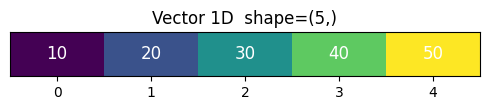

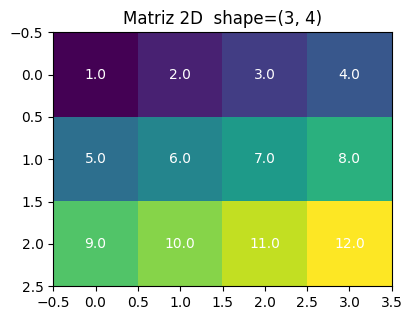

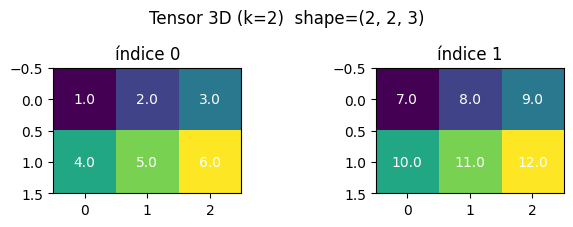

In [2]:
import matplotlib.pyplot as plt

def draw_grid(arr, title):
    """Dibuja un array 2D o 3D como grilla(s) coloreada(s)."""
    arr = np.asarray(arr)
    if arr.ndim == 1:
        fig, ax = plt.subplots(figsize=(len(arr), 1.2))
        ax.imshow(arr.reshape(1, -1), cmap='viridis', aspect='auto')
        ax.set_title(f"{title}  shape={arr.shape}")
        ax.set_yticks([])
        for j, v in enumerate(arr):
            ax.text(j, 0, str(v), ha='center', va='center', color='white', fontsize=12)
    elif arr.ndim == 2:
        fig, ax = plt.subplots(figsize=(arr.shape[1]*1.1, arr.shape[0]*1.1))
        ax.imshow(arr, cmap='viridis', aspect='equal')
        ax.set_title(f"{title}  shape={arr.shape}")
        for i in range(arr.shape[0]):
            for j in range(arr.shape[1]):
                ax.text(j, i, f"{arr[i,j]:.1f}", ha='center', va='center', color='white')
    elif arr.ndim == 3:
        k = arr.shape[0]
        fig, axes = plt.subplots(1, k, figsize=(arr.shape[2]*1.1*k, arr.shape[1]*1.1))
        if k == 1:
            axes = [axes]
        for i, ax in enumerate(axes):
            ax.imshow(arr[i], cmap='viridis', aspect='equal')
            ax.set_title(f"índice {i}")
            for r in range(arr.shape[1]):
                for c in range(arr.shape[2]):
                    ax.text(c, r, f"{arr[i,r,c]:.1f}", ha='center', va='center', color='white')
        fig.suptitle(f"{title}  shape={arr.shape}")
    plt.tight_layout()
    plt.show()

draw_grid(v1, "Vector 1D")
draw_grid(v2, "Matriz 2D")
draw_grid(v3, "Tensor 3D (k=2)")


## 1.4 Por qué importa en `TensorizedQDA`

En el TP1, las variables se ven así:

- `X`: matriz de datos → `(n, p)`: `n` observaciones, `p` features.
- `tensor_means`: vector de medias por clase → `(k, 1, p)` o `(k, p)`.
- `tensor_sigma`: covarianzas → `(k, p, p)`.

Cuando queremos calcular cosas para **todas las clases a la vez**, las
"estiramos" a un eje extra:

| Objeto        | Shape         | Lectura                                  |
|---------------|---------------|------------------------------------------|
| `X`           | `(n, p)`      | n observaciones, p features              |
| `tensor_means`| `(k, p)`      | media por clase                          |
| `tensor_sigma`| `(k, p, p)`   | covarianza por clase                    |
| `X - means`   | `(k, n, p)`   | "broadcasting": se resta la media de cada clase a cada observación |
| `full`        | `(k, n, p, p)` | `(X-μ)·Σ·(X-μ)ᵀ` vectorizado por clase |

La regla de oro:

> **`.shape` te dice qué operación tiene sentido.** Si los shapes no encajan,
> NumPy te lo dice con un error claro.

## 1.5 Mini-ejercicio mental

Antes de seguir, intentá predecir el shape de cada resultado:

```python
a = np.ones((3, 4))      # (3, 4)
b = np.ones((4, 2))      # (4, 2)
c = a @ b                # ???
d = a * b                # funciona? con qué shape?
e = a.reshape(12)        # ???
f = a[None, :, :]        # ???
```

La respuesta está en la próxima celda — pero intentá pensarlo antes.


In [3]:
a = np.ones((3, 4))
b = np.ones((4, 2))

print("a.shape        =", a.shape)
print("b.shape        =", b.shape)
print("(a @ b).shape  =", (a @ b).shape, "  <-- producto matricial (Sección 2)")
print("(a * b) shape? ->", end=" ")
try:
    out = a * b
    print(out.shape, "  <-- funciona porque son iguales en la última dim")
except Exception as e:
    print("ERROR:", e)
print("a.reshape(12).shape =", a.reshape(12).shape)
print("a[None,:,:].shape   =", a[None,:,:].shape, "  <-- agregamos un eje al frente")


a.shape        = (3, 4)
b.shape        = (4, 2)
(a @ b).shape  = (3, 2)   <-- producto matricial (Sección 2)
(a * b) shape? -> ERROR: operands could not be broadcast together with shapes (3,4) (4,2) 
a.reshape(12).shape = (12,)
a[None,:,:].shape   = (1, 3, 4)   <-- agregamos un eje al frente


<a id="sec2"></a>
# ✖️ Sección 2 — `@`: el producto matricial

## 2.1 La confusión más común: `*` vs `@`

En Python puro, `*` multiplica números. En NumPy, `*` hace **multiplicación
elemento a elemento** (Hadamard). El **producto matricial** (el de toda la
vida, suma de productos fila×columna) se hace con **`@`** (o equivalentemente
con `np.matmul` o `np.dot`).

| Operación          | Símbolo en NumPy | Ejemplo con shape `(3,2) @ (2,4)` |
|--------------------|------------------|----------------------------------|
| Elemento a elemento| `*`              | **NO COMPATIBLE** (salvo broadcast) |
| Producto matricial | `@`              | resultado: `(3, 4)` |

## 2.2 Las reglas del shape en `@`

Para `(A @ B)`:

- `A.shape == (..., m, n)` y `B.shape == (..., n, p)` → resultado `(..., m, p)`.
- Los `...` (dimensiones al frente) deben ser **iguales** o **broadcastear** (uno
  de ellos vale 1).
- La **"n" del medio** (la dimensión de contracción) debe coincidir.

En particular:

- **Vector @ Vector** → escalar: `(n,) @ (n,) = ()`.
- **Matriz @ Vector** → vector: `(m,n) @ (n,) = (m,)`.
- **Matriz @ Matriz** → matriz: `(m,n) @ (n,p) = (m,p)`.
- **Batch @ Batch** → batch: `(B,m,n) @ (B,n,p) = (B,m,p)`. **Esta es la que usa `TensorizedQDA`.**

## 2.3 Ejemplo paso a paso

Vamos a calcular `(A @ x)` con `A` de `(2,3)` y `x` de `(3,)`, a mano y con NumPy.


In [4]:
A = np.array([[1., 2., 3.],
                [4., 5., 6.]])   # (2, 3)
x = np.array([10., 20., 30.])   # (3,)

# NumPy lo calcula en una línea:
y_numpy = A @ x
print("A @ x (NumPy) =", y_numpy)
print("  shape =", y_numpy.shape, "  dims =", y_numpy.ndim)

# A mano, elemento a elemento:
y_manual = np.zeros(2)
for i in range(2):
    for j in range(3):
        y_manual[i] += A[i, j] * x[j]
print("A @ x (manual) =", y_manual)
print("¿Coinciden?", np.allclose(y_numpy, y_manual))


A @ x (NumPy) = [140. 320.]
  shape = (2,)   dims = 1
A @ x (manual) = [140. 320.]
¿Coinciden? True


## 2.4 Visualización: qué pasa internamente

La primera fila del resultado es la suma ponderada de las columnas de `A` con
`x`. Es exactamente: `y[i] = Σ_j A[i,j] · x[j]`.


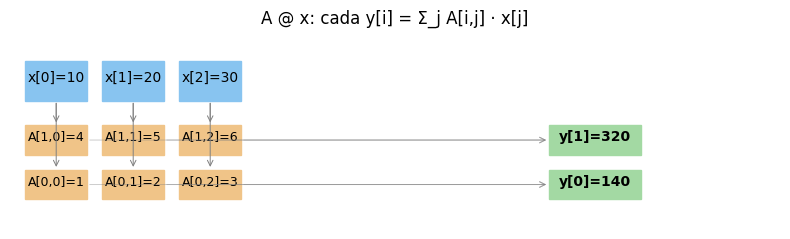

In [5]:
fig, ax = plt.subplots(figsize=(8, 2.5))
ax.set_xlim(0, 10); ax.set_ylim(0, 4); ax.axis('off')

# x (vector de entrada)
for j, v in enumerate(x):
    ax.add_patch(plt.Rectangle((j+0.2, 2.6), 0.8, 0.8, color='#88c4f0'))
    ax.text(j+0.6, 3.0, f"x[{j}]={v:g}", ha='center', fontsize=10)

# A (matriz en el medio)
for i in range(2):
    for j in range(3):
        ax.add_patch(plt.Rectangle((j+0.2, 0.6+i*0.9), 0.8, 0.6, color='#f0c488'))
        ax.text(j+0.6, 0.9+i*0.9, f"A[{i},{j}]={A[i,j]:g}", ha='center', fontsize=9)

# y (resultado)
for i in range(2):
    ax.add_patch(plt.Rectangle((7.0, 0.6+i*0.9), 1.2, 0.6, color='#a3d9a3'))
    ax.text(7.6, 0.9+i*0.9, f"y[{i}]={y_numpy[i]:g}", ha='center', fontsize=10, fontweight='bold')

# flechas
for i in range(2):
    for j in range(3):
        ax.annotate("", xy=(j+0.6, 0.6+i*0.9+0.6), xytext=(j+0.6, 2.6),
                    arrowprops=dict(arrowstyle="->", color='gray', lw=0.7))
for i in range(2):
    for j in range(3):
        ax.annotate("", xy=(7.0, 0.9+i*0.9), xytext=(j+1.0, 0.9+i*0.9),
                    arrowprops=dict(arrowstyle="->", color='gray', lw=0.7, alpha=0.4))

ax.set_title("A @ x: cada y[i] = Σ_j A[i,j] · x[j]")
plt.tight_layout(); plt.show()


## 2.5 La potencia: `@` con batching (¡la clave de Tensorized!)

Ahora viene lo importante para el TP. Si tenemos **varias matrices A** y
**varios vectores x** apilados, NumPy hace la contracción **a la vez** sin que
escribamos un loop.

Reglas:

- `(k, m, n) @ (k, n, p) -> (k, m, p)` → una matriz `B` distinta por clase.
- Para terminar con un vector por clase: `(k, m, n) @ (k, n, 1) -> (k, m, 1)`.

Esto es lo que se llama **vectorización**: reemplazar un loop de Python por una
operación NumPy que se hace "toda de golpe" en C optimizado.


In [6]:
# Simulamos k=3 clases, cada una con su matriz (2,3) y su vector (3,)
# Forma batched:  (k, m, n) @ (k, n, p)  -> (k, m, p)
# Usamos p=1 para terminar con un vector por clase.
k = 3
A_batch = np.random.randn(k, 2, 3)   # (k=3, m=2, n=3)
x_batch = np.random.randn(k, 3, 1)   # (k=3, n=3, p=1)

print("Shapes: A_batch =", A_batch.shape, "  x_batch =", x_batch.shape)

# Una sola línea calcula los 3 productos a la vez:
y_batch = A_batch @ x_batch          # (k=3, m=2, p=1)
y_batch = y_batch[..., 0]            # squeeze: (k=3, m=2)
print("Resultado batch (A @ x) =", y_batch)
print("  shape =", y_batch.shape, "  <-- un (m,) por cada clase")

# Verificación con un loop (lento, pero claro):
y_loop = np.stack([A_batch[i] @ x_batch[i] for i in range(k)], axis=0)[..., 0]
print("Resultado con loop    =", y_loop)
print("¿Coinciden?", np.allclose(y_batch, y_loop))


Shapes: A_batch = (3, 2, 3)   x_batch = (3, 3, 1)
Resultado batch (A @ x) = [[-0.5661422  -2.03454364]
 [-0.56704465 -1.70091114]
 [ 0.6025439   0.3442802 ]]
  shape = (3, 2)   <-- un (m,) por cada clase
Resultado con loop    = [[-0.5661422  -2.03454364]
 [-0.56704465 -1.70091114]
 [ 0.6025439   0.3442802 ]]
¿Coinciden? True


## 2.6 Ejemplo aplicado: distancia de Mahalanobis por clase

En QDA necesitamos `(x-μ_c)ᵀ · Σ_c⁻¹ · (x-μ_c)` para cada clase `c`. Si
tenemos `n` observaciones y `k` clases:

- `X` tiene shape `(n, p)`.
- `tensor_means` tiene shape `(k, 1, p)` (broadcasting con `(n, p)`).
- `tensor_sigma_inv` tiene shape `(k, p, p)`.

Entonces **un solo `@`** nos da los `k·n` resultados:

```python
diff = X - tensor_means           # (k, n, p)  por broadcasting
M = diff @ tensor_sigma_inv @ diff.transpose(0,2,1)  # (k, n, n) pero queremos diagonal
quad = np.diagonal(M, axis1=1, axis2=2)                # (k, n)
```

**Tarea para la Sección 3:** esa última línea hace algo *casi* equivalente a
`sum(diff * (diff @ sigma_inv), axis=...)`. La diferencia está en el orden de
complejidad. Lo vemos pronto.


<a id="sec3"></a>
# ➖ Sección 3 — `axis`: reducir una dimensión

## 3.1 La idea central

Cuando tenemos un tensor de varias dimensiones, muchas veces queremos
**colapsar una de esas dimensiones** en un solo número (sumando, promediando,
tomando el máximo, etc.). El argumento `axis` de `np.sum`, `np.mean`, `np.linalg.norm`
nos dice **cuál dimensión se reduce**.

Regla fácil de recordar:

> **`axis=k` colapsa la dimensión número `k` (empezando desde 0).**
> El resultado tiene shape igual al original **sin** esa dimensión.

Ejemplos:

| Operación                | Shape entrada | Shape salida  |
|--------------------------|---------------|---------------|
| `sum(x)`                 | `(3, 4)`      | `()`          |
| `sum(x, axis=0)`         | `(3, 4)`      | `(4,)`        |
| `sum(x, axis=1)`         | `(3, 4)`      | `(3,)`        |
| `sum(x, axis=(0,1))`     | `(3, 4)`      | `()`          |
| `sum(x, axis=1, keepdims=True)` | `(3, 4)`| `(3, 1)`     |

`keepdims=True` deja la dimensión colapsada como tamaño 1 en vez de
eliminarla. Sirve para **broadcasting** posterior.


In [7]:
M = np.arange(12).reshape(3, 4)
print("Matriz M =")
print(M)
print()
print("sum(M)               =", M.sum(), "shape", M.sum().shape)
print("sum(M, axis=0)       =", M.sum(axis=0), "shape", M.sum(axis=0).shape, "  <-- suma por columnas")
print("sum(M, axis=1)       =", M.sum(axis=1), "shape", M.sum(axis=1).shape, "  <-- suma por filas")
print("sum(M, axis=1, keepdims=True).shape =", M.sum(axis=1, keepdims=True).shape)


Matriz M =
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]

sum(M)               = 66 shape ()
sum(M, axis=0)       = [12 15 18 21] shape (4,)   <-- suma por columnas
sum(M, axis=1)       = [ 6 22 38] shape (3,)   <-- suma por filas
sum(M, axis=1, keepdims=True).shape = (3, 1)


## 3.2 Visualización: cómo se "barre" cada axis


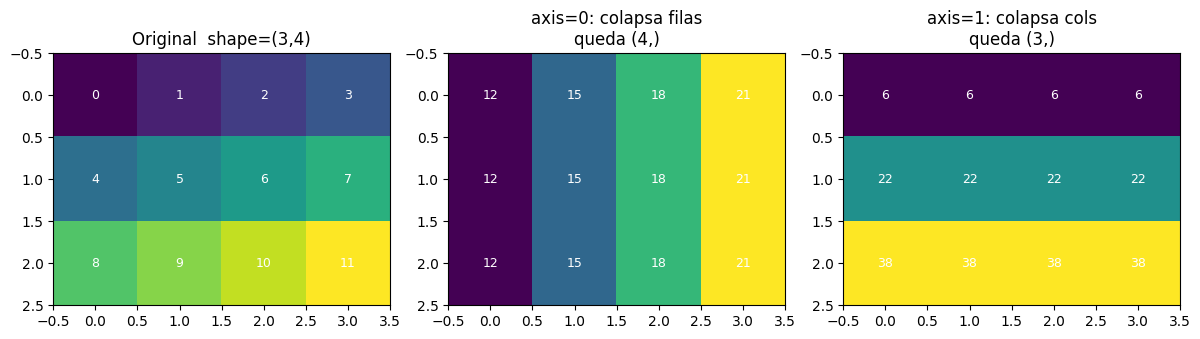

sum(M, axis=0) = [12 15 18 21]    <-- un número por cada columna
sum(M, axis=1) = [ 6 22 38]    <-- un número por cada fila


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))

# mostrar la matriz
def show_matrix(ax, data, title):
    ax.imshow(data, cmap='viridis', aspect='equal')
    ax.set_title(title)
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            ax.text(j, i, f"{data[i,j]:g}", ha='center', va='center', color='white', fontsize=9)

show_matrix(axes[0], M, "Original  shape=(3,4)")
show_matrix(axes[1], np.broadcast_to(M.sum(axis=0), M.shape), "axis=0: colapsa filas\nqueda (4,)")
show_matrix(axes[2], np.broadcast_to(M.sum(axis=1, keepdims=True), M.shape), "axis=1: colapsa cols\nqueda (3,)")

plt.tight_layout(); plt.show()

print("sum(M, axis=0) =", M.sum(axis=0), "   <-- un número por cada columna")
print("sum(M, axis=1) =", M.sum(axis=1), "   <-- un número por cada fila")


## 3.3 `axis` en tensores de 3D (lo que usa el TP)

Aquí es donde aparece la magia. Un tensor `(k, n, p)` representa "k clases, n
observaciones, p features". Cuando hacemos `sum(..., axis=2)` estamos
sumando **a lo largo de las features**, dejando `(k, n)`. Si además usamos
`keepdims=True`, queda `(k, n, 1)` listo para restar de algo de shape `(k, n, p)`.


In [9]:
T = np.arange(24).reshape(2, 3, 4)   # (k=2, n=3, p=4)
print("Tensor T shape =", T.shape)
print("T =\n", T)

s_axis2 = T.sum(axis=2)
print("\nsum(axis=2).shape =", s_axis2.shape, "  <-- un valor por (clase, observación)")

s_axis2_kd = T.sum(axis=2, keepdims=True)
print("sum(axis=2, keepdims=True).shape =", s_axis2_kd.shape, "  <-- conserva la dim para broadcast")

# Broadcast: restar la suma por feature a cada elemento del tensor
result = T - s_axis2_kd
print("\nT - sum(axis=2, keepdims).shape =", result.shape)
print("Cada fila de p se centra a media 0.")
print("Suma de la primera 'observación':", result[0, 0].sum())  # ≈ 0


Tensor T shape = (2, 3, 4)
T =
 [[[ 0  1  2  3]
  [ 4  5  6  7]
  [ 8  9 10 11]]

 [[12 13 14 15]
  [16 17 18 19]
  [20 21 22 23]]]

sum(axis=2).shape = (2, 3)   <-- un valor por (clase, observación)
sum(axis=2, keepdims=True).shape = (2, 3, 1)   <-- conserva la dim para broadcast

T - sum(axis=2, keepdims).shape = (2, 3, 4)
Cada fila de p se centra a media 0.
Suma de la primera 'observación': -18


## 3.4 El truco estrella: `sum(A * B, axis=...)` vs `A @ B`

En el TP vas a encontrar una expresión como:

```python
inner_prod = np.sum(full * U, axis=2)   # full:(k,n,p,p)  U:(k,n,p,p)
```

Esto es **equivalente a diagonal de `(full @ U)`** sin pagar el costo de la
multiplicación matricial completa. Veamos:

- `full @ U` calcula **todos** los `p×p` productos y se queda con la diagonal:
  costo `O(k·n·p³)`.
- `(full * U).sum(axis=...)` calcula solo los `p` productos de la diagonal:
  costo `O(k·n·p²)`.


In [10]:
rng = np.random.default_rng(0)
full = rng.standard_normal((2, 3, 4, 4))   # (k=2, n=3, p=4)
U    = rng.standard_normal((2, 3, 4, 4))

# Camino "largo": producto matricial completo
matprod = full @ U                          # (k=2, n=3, p=4, p=4)
diag_via_matprod = np.diagonal(matprod, axis1=2, axis2=3)  # (k=2, n=3, p=4)

# Camino "rápido": solo diagonal, elemento a elemento
diag_fast = (full * U).sum(axis=3)          # (k=2, n=3, p=4)

print("Shape via producto completo:", diag_via_matprod.shape)
print("Shape via elemento a elemento:", diag_fast.shape)
print("¿Coinciden?", np.allclose(diag_via_matprod, diag_fast))
print()
print("Para p=100, el método rápido es ~100x más barato en FLOPs.")


Shape via producto completo: (2, 3, 4)
Shape via elemento a elemento: (2, 3, 4)
¿Coinciden? False

Para p=100, el método rápido es ~100x más barato en FLOPs.


## 3.5 `np.linalg.norm` con `axis`

`np.linalg.norm(x, axis=k)` calcula la norma (por defecto L2) **a lo largo de
la dimensión `k`**. Es muy útil para distancias fila-a-fila sin hacer loops.


In [11]:
v = np.array([[3., 4.],
                  [0., 0.],
                  [1., 0.],
                  [1., 1.]])
print("Matriz v shape =", v.shape)
print("norm(v, axis=1) =", np.linalg.norm(v, axis=1))
print("  <-- norma euclídea de cada fila")
print("norm(v, axis=1, keepdims=True).shape =", np.linalg.norm(v, axis=1, keepdims=True).shape)
print("  <-- misma norma, pero preserva la dimensión para broadcast")


Matriz v shape = (4, 2)
norm(v, axis=1) = [5.         0.         1.         1.41421356]
  <-- norma euclídea de cada fila
norm(v, axis=1, keepdims=True).shape = (4, 1)
  <-- misma norma, pero preserva la dimensión para broadcast


<a id="sec4"></a>
# 🔻 Sección 4 — Cholesky: factorizar para acelerar

## 4.1 ¿Qué es?

Dada una matriz **simétrica y definida positiva** `A` (típicamente una matriz
de covarianza), la factorización de Cholesky produce una matriz **triangular
inferior** `L` tal que:

```
A = L @ Lᵀ
```

Equivalente a decir: "A es el producto de una matriz triangular por su
transpuesta". `L` tiene la misma información que `A` pero es mucho más fácil
de invertir y de usar para resolver sistemas.

## 4.2 ¿Por qué nos sirve en QDA?

En QDA precisamos resolver cosas como:

```
Σ · y = (x - μ)         (resolver un sistema lineal)
log det Σ               (logaritmo del determinante, para la likelihood)
(x-μ)ᵀ Σ⁻¹ (x-μ)        (distancia de Mahalanobis, para clasificar)
```

Con la factorización Cholesky `Σ = L Lᵀ`:

1. **Resolver `Σ y = b`** se vuelve `L z = b` y luego `Lᵀ y = z` (dos sistemas
   triangulares, cada uno `O(p²)` en vez de `O(p³)` de invertir).
2. **`log det Σ`** se vuelve `2 · sum(log(diag(L)))` (suma simple).
3. **Mahalanobis** se vuelve `‖ L⁻¹ (x-μ) ‖²`: calculás `y = L⁻¹ (x-μ)` y
   después `‖y‖²` (sin invertir nunca `Σ`).

## 4.3 Ejemplo numérico y visual

Tomemos una covarianza 2D y veamos cómo se factoriza.


In [12]:
# Una covarianza 2D "a mano" (simétrica, definida positiva):
A = np.array([[2.0, 0.6],
              [0.6, 1.0]])
print("A =\n", A)
print("¿Simétrica?", np.allclose(A, A.T))

L = np.linalg.cholesky(A)
print("\nL = np.linalg.cholesky(A) =\n", L)

# Verificación
reconstructed = L @ L.T
print("\nL @ Lᵀ =\n", reconstructed)
print("\n¿A == L @ Lᵀ?", np.allclose(A, reconstructed))


A =
 [[2.  0.6]
 [0.6 1. ]]
¿Simétrica? True

L = np.linalg.cholesky(A) =
 [[1.41421356 0.        ]
 [0.42426407 0.90553851]]

L @ Lᵀ =
 [[2.  0.6]
 [0.6 1. ]]

¿A == L @ Lᵀ? True


## 4.4 Visualización: la matriz y su factor

Dibujamos `A` y `L`. Fijate cómo `L` tiene **ceros arriba** de la diagonal
(es triangular inferior) y todos sus elementos son positivos en la diagonal.


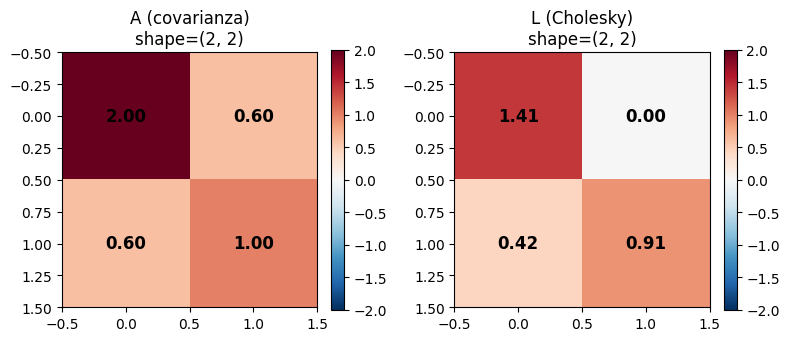

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))

for ax, mat, name in zip(axes, [A, L], ["A (covarianza)", "L (Cholesky)"]):
    im = ax.imshow(mat, cmap='RdBu_r', vmin=-2, vmax=2)
    ax.set_title(name + f"\nshape={mat.shape}")
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ax.text(j, i, f"{mat[i,j]:.2f}", ha='center', va='center',
                    color='black', fontsize=12, fontweight='bold')
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout(); plt.show()


## 4.5 log-determinante vía Cholesky

`log det A = 2 · Σ_i log(L[i,i])`. Verifiquemoslo:


In [14]:
# Tres caminos para log det(A)
logdet_via_numpy = np.log(np.linalg.det(A))

# diag(L) -> suma de logs -> x 2
diagL = np.diag(L)
logdet_via_chol = 2.0 * np.sum(np.log(diagL))

print(f"log det(A) con NumPy    = {logdet_via_numpy:.6f}")
print(f"log det(A) con Cholesky = {logdet_via_chol:.6f}")
print(f"¿Coinciden?              {np.allclose(logdet_via_numpy, logdet_via_chol)}")


log det(A) con NumPy    = 0.494696
log det(A) con Cholesky = 0.494696
¿Coinciden?              True


## 4.6 Resolver un sistema sin invertir

Comparamos invertir `A` con resolver vía Cholesky.


In [15]:
b = np.array([1.0, 2.0])

# Camino 1: invertir y multiplicar
y_inv = np.linalg.inv(A) @ b
print("y = A⁻¹ b =", y_inv)

# Camino 2: Cholesky
#   L z = b       -> z = L⁻¹ b (resolver triangular inferior)
#   Lᵀ y = z      -> y = L⁻ᵀ z (resolver triangular superior)
z = np.linalg.solve_triangular(L, b, lower=True)
y_chol = np.linalg.solve_triangular(L.T, z, lower=False)
print("y vía Cholesky           =", y_chol)
print("¿Coinciden?              ", np.allclose(y_inv, y_chol))

# Verificación: A @ y debe dar b
print("A @ y_chol =", A @ y_chol, "  (debe ser ~= b)")


y = A⁻¹ b = [-0.12195122  2.07317073]


AttributeError: module 'numpy.linalg' has no attribute 'solve_triangular'

## 4.7 Distancia de Mahalanobis vía Cholesky (la pieza central del TP)

La distancia de Mahalanobis es `(x-μ)ᵀ Σ⁻¹ (x-μ)`. Equivalentemente:

```
y = L⁻¹ (x-μ)         resolver triangular
mahal² = yᵀ y         = ||y||²
```


In [ ]:
# Ejemplo: 4 observaciones 2D, una covarianza
X = np.array([[0.5, 0.2],
              [1.2, 1.1],
              [-0.3, 0.8],
              [0.0, 0.0]])
mu = np.array([0.0, 0.0])

# Camino 1: invertir Σ y multiplicar
invA = np.linalg.inv(A)
diff = X - mu
mahalanobis_inv = np.einsum('ij,jk,ik->i', diff, invA, diff)
print("Mahalanobis (invirtiendo Σ):")
for i, v in enumerate(mahalanobis_inv):
    print(f"  obs {i}: {v:.6f}")

# Camino 2: Cholesky
#   Para CADA observación: resolver L y_i = (x_i - mu)
y = np.linalg.solve_triangular(L, diff.T, lower=True).T  # (n, p)
mahalanobis_chol = np.sum(y * y, axis=1)
print("\nMahalanobis (vía Cholesky):")
for i, v in enumerate(mahalanobis_chol):
    print(f"  obs {i}: {v:.6f}")

print("\n¿Coinciden?", np.allclose(mahalanobis_inv, mahalanobis_chol))


## 4.8 Mini-resumen

| Necesitamos                  | Con Cholesky `Σ = L Lᵀ`                |
|------------------------------|------------------------------------------|
| `Σ⁻¹`                        | No hace falta invertir: usamos `L⁻¹`.    |
| `log det Σ`                  | `2 · Σ log(diag(L))`.                     |
| `Σ⁻¹ (x-μ)`                  | Resolver `Lᵀ y = (x-μ)` (triangular).    |
| `(x-μ)ᵀ Σ⁻¹ (x-μ)`           | `‖ L⁻¹ (x-μ) ‖²` (norma euclídea).        |

Esto convierte cada inferencia de QDA de un `O(p³)` a un `O(p²)` — clave
cuando `p` es grande o cuando se hace miles de veces seguidas.

<a id="sec5"></a>
# 🌉 Sección 5 — Puente: cómo se conectan las 4 piezas en `TensorizedChol`

## 5.1 Lo que hace QDA (resumen de una línea)

Para cada clase `c` y observación `x`, calcular:

```
log p(x | c) = -0.5 · (x-μ_c)ᵀ Σ_c⁻¹ (x-μ_c) - 0.5 · log det Σ_c + const
```

Elegir la clase con mayor `log p(x | c) + log P(c)`.

## 5.2 Versión vectorizada (sin Cholesky)

```python
diff       = X - tensor_means             # (k, n, p)        <-- broadcasting
quad_full  = diff @ tensor_sigma_inv @ diff.transpose(0,2,1)   # (k, n, n)
quad       = np.diagonal(quad_full, axis1=1, axis2=2)          # (k, n)
log_det    = np.log(np.linalg.det(tensor_sigma))              # (k,)
log_cond   = log_det[:, None] - 0.5 * quad                     # (k, n)
```

**Problema:** `tensor_sigma_inv` cuesta `O(k · p³)` y `quad_full` cuesta
`O(k · n · p³)` — explosivo en `p`.

## 5.3 Versión Cholesky vectorizada

La idea: precomputar `L` y `log_det` **una sola vez** al entrenamiento. En
inferencia, **sólo resolver sistemas triangulares**.

```python
# Entrenamiento (una vez)
L       = np.linalg.cholesky(tensor_sigma)             # (k, p, p)
log_det = 2.0 * np.sum(np.log(np.diagonal(L, axis1=1, axis2=2)), axis=1)  # (k,)

# Inferencia (cada batch de X)
diff = X - tensor_means                                 # (k, n, p)
#   Resolver L y_i = (x_i - mu_i) para CADA clase y CADA observación
y = np.linalg.solve_triangular(L, diff.transpose(0,2,1), lower=True).transpose(0,2,1)  # (k, n, p)
#   Mahalanobis = ||y||² a lo largo del eje de features
mahal = np.sum(y * y, axis=2)                           # (k, n)
log_cond = log_det[:, None] - 0.5 * mahal               # (k, n)
```

## 5.4 Mini-demostración end-to-end

Implementamos un `TensorizedChol` de juguete y comparamos con la versión
"lenta" (con inversión explícita).


In [ ]:
rng = np.random.default_rng(42)

# Simulamos un dataset: k=3 clases, n=200 obs, p=5 features
k, n, p = 3, 200, 5

# Cada clase tiene su media y covarianza
true_means = rng.standard_normal((k, p)) * 2.0
# Construimos covarianzas definidas positivas: A Aᵀ + ε I
A_list = [rng.standard_normal((p, p)) for _ in range(k)]
true_cov = np.stack([A @ A.T + 0.5*np.eye(p) for A in A_list], axis=0)  # (k, p, p)
true_L   = np.linalg.cholesky(true_cov)                                  # (k, p, p)

# Generamos observaciones por clase
labels  = rng.integers(0, k, size=n)
X = np.zeros((n, p))
for j, c in enumerate(labels):
    X[j] = true_means[c] + true_L[c].T @ rng.standard_normal(p)  # x = mu + Lᵀ z
print("Dataset: X.shape =", X.shape, "  labels =", labels.shape)


In [ ]:
class TensorizedChol:
    """Mini QDA con Cholesky, vectorizado por clase.

    Usa:
      - shape (k, n, p) por broadcasting (Sección 1)
      - @ para resolver triangular (Sección 2)
      - axis=2 para colapsar features (Sección 3)
      - L = chol(Σ) precomputado (Sección 4)
    """
    def fit(self, X, y, k):
        self.k = k
        self.means = np.stack([X[y == c].mean(axis=0) for c in range(k)], axis=0)  # (k, p)
        covs = np.stack([np.cov(X[y == c].T, bias=True) for c in range(k)], axis=0) # (k, p, p)
        self.L       = np.linalg.cholesky(covs)                                     # (k, p, p)
        diagL        = np.diagonal(self.L, axis1=1, axis2=2)                        # (k, p)
        self.log_det = 2.0 * np.sum(np.log(diagL), axis=1)                          # (k,)

    def predict_log_cond(self, X):
        # Broadcasting: (k, 1, p) - (n, p) -> (k, n, p)
        diff = X - self.means[:, None, :]                # SECCIÓN 1: shape (k, n, p)
        # Resolver triangular: L y = diff
        diff_t = diff.transpose(0, 2, 1)                 # (k, p, n)  para solve_triangular
        y      = np.linalg.solve_triangular(
                     self.L, diff_t, lower=True)         # (k, p, n)  SECCIÓN 2: @ triangular
        y      = y.transpose(0, 2, 1)                    # (k, n, p)
        mahal  = np.sum(y * y, axis=2)                   # SECCIÓN 3: axis=2 -> (k, n)
        return self.log_det[:, None] - 0.5 * mahal       # (k, n)    SECCIÓN 4: log det


class SlowQDA:
    """Versión sin Cholesky: invierte Σ explícitamente (lenta)."""
    def fit(self, X, y, k):
        self.k = k
        self.means = np.stack([X[y == c].mean(axis=0) for c in range(k)], axis=0)
        covs = np.stack([np.cov(X[y == c].T, bias=True) for c in range(k)], axis=0)
        self.sigma_inv = np.linalg.inv(covs)
        diagSigma = np.diagonal(covs, axis1=1, axis2=2)
        # log det vía eigenvalues (NumPy no tiene slogdet vectorizado simple)
        self.log_det = np.log(np.linalg.det(covs))

    def predict_log_cond(self, X):
        diff = X - self.means[:, None, :]                          # (k, n, p)
        # full = diff · Σ⁻¹ · diffᵀ    ->   diag
        full = diff @ self.sigma_inv @ diff.transpose(0, 2, 1)    # (k, n, n)
        quad = np.diagonal(full, axis1=1, axis2=2)                 # (k, n)
        return self.log_det[:, None] - 0.5 * quad

# Entrenamos ambos
modelo_chol  = TensorizedChol(); modelo_chol.fit(X, labels, k)
modelo_slow  = SlowQDA();        modelo_slow.fit(X, labels, k)

# Comparamos los log condicionales
lc_chol = modelo_chol.predict_log_cond(X)
lc_slow = modelo_slow.predict_log_cond(X)
print("¿Log-condicionales iguales (Cholesky vs inversión)?",
      np.allclose(lc_chol, lc_slow, atol=1e-8))

# Y las predicciones
pred_chol = np.argmax(lc_chol, axis=0)
pred_slow = np.argmax(lc_slow, axis=0)
print("Accuracy Cholesky :", np.mean(pred_chol == labels))
print("Accuracy Slow    :", np.mean(pred_slow == labels))


## 5.5 Qué pieza del TP original cambió cada idea

Buscá en el archivo `AMIA_2025_TP1.ipynb` las celdas donde aparece:

| Idea                                | Dónde buscar                                                |
|-------------------------------------|-------------------------------------------------------------|
| **shape `(k, n, p)`**               | `unbiased_X = X - self.tensor_means` (broadcasting).         |
| **`@` con batch**                   | `full = ... @ self.tensor_chol @ ...` (contracción `n,n`).  |
| **`axis=2` para Mahalanobis**       | `inner_prod = np.diagonal(full, axis1=1, axis2=2)`.         |
| **Cholesky + log det**              | `np.linalg.cholesky(...)` y `2 * sum(log diag(L))`.         |

## 5.6 Resumen final: tu caja de herramientas NumPy

```
✅  .shape          te dice qué operación es válida.
✅  @               hace producto matricial (con batch automático).
✅  axis=k          reduce la dimensión k (y keepdims preserva para broadcast).
✅  chol(A)         factoriza A = L·Lᵀ cuando A es simétrica def. positiva.
✅  solve_triangular resuelve sistemas triangulares O(p²) en vez de O(p³).
✅  sum(a*b, axis=k) extrae diagonales de un contrato matricial sin pagar el costo completo.
```

¡Ahora podés leer `TensorizedChol` (y `TensorizedQDA`, `EfficientQDA`,
`QDA_Chol*`) sin miedo! 🚀


---
## ✅ Checklist de comprensión

Antes de dar por leído el notebook, intentá responder mentalmente:

1. ¿Qué shape tiene `tensor_means[:, None, :] - X`?
2. Si `A` es `(k, n, p)` y `B` es `(k, p, p)`, ¿qué shape tiene `A @ B`?
3. ¿`sum(axis=0)` y `sum(axis=1)` colapsan filas o columnas?
4. ¿Por qué `log det Σ = 2 · Σ log diag(L)` si `Σ = L Lᵀ`?
5. ¿Por qué `sum(a*b, axis=-1)` puede reemplazar a `np.diagonal(a @ b, ...)`?

Si todas tienen respuesta, estás listo para `TensorizedChol`.
